<a href="https://colab.research.google.com/github/Misnna/MYDAILYWORK/blob/main/image_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch torchvision pillow matplotlib


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

# Load BLIP model + processor
model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("BLIP image captioning model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP image captioning model loaded successfully!


In [3]:
from google.colab import files

# Upload an image from your computer
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print("Uploaded Image:", image_path)

Saving car.webp to car.webp
Uploaded Image: car.webp


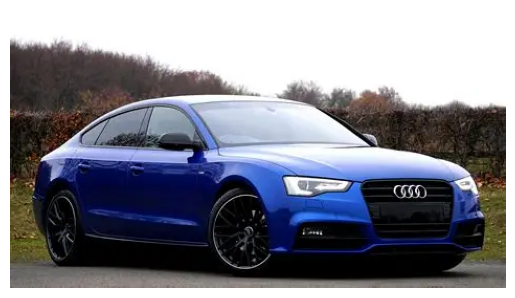

In [4]:
# Open the image using PIL
img = Image.open(image_path)

# Display the image using matplotlib
plt.imshow(img)
plt.axis("off")  # Hide axes
plt.show()

In [5]:
def generate_caption(image_path):
    # Open the image and convert to RGB
    img = Image.open(image_path).convert("RGB")

    # Prepare the image for the model
    inputs = processor(images=img, return_tensors="pt").to(device)

    # Generate caption
    out = model.generate(**inputs)

    # Decode the caption
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# Generate caption for your uploaded image
caption = generate_caption(image_path)
print("Generated Caption:")
print(caption)

Generated Caption:
audi rs5 rs5 rs5 rs5 rs5 rs5 rs5 rs5 rs5 rs


In [6]:
out = model.generate(**inputs, max_new_tokens=50, num_beams=5)

NameError: name 'inputs' is not defined

In [7]:
def generate_caption(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    # Use beam search and limit caption length
    out = model.generate(**inputs, max_new_tokens=50, num_beams=5)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

In [8]:
# Generate caption for the uploaded image
caption = generate_caption(image_path)

# Print the generated caption
print("Generated Caption:")
print(caption)

Generated Caption:
a blue car parked on the side of a road


In [9]:
def generate_caption_clean(image_path):
    img = Image.open(image_path).convert("RGB")

    # Add a prompt for generic caption
    inputs = processor(images=img, text="a photo of", return_tensors="pt").to(device)

    # Generate caption
    out = model.generate(**inputs, max_new_tokens=50, num_beams=5)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# Generate clean caption
caption_clean = generate_caption_clean(image_path)
print("Generated Clean Caption:")
print(caption_clean)

Generated Clean Caption:
a photo of a blue audi car parked on the side of a road


In [10]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded Image:", image_path)

Saving supra.jpg to supra.jpg
Uploaded Image: supra.jpg


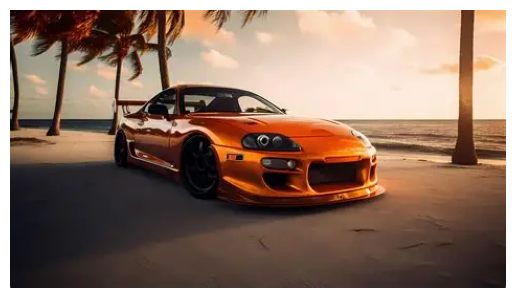

In [11]:
img = Image.open(image_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
# For normal captions
caption = generate_caption(image_path)
print("Generated Caption:")
print(caption)

# For clean captions (avoid brand names)
caption_clean = generate_caption_clean(image_path)
print("Generated Clean Caption:")
print(caption_clean)

Generated Caption:
a car parked on the beach with palm trees in the background
Generated Clean Caption:
a photo of a car parked on the beach with palm trees in the background


Saving supra.jpg to supra (1).jpg
Saving car.webp to car (1).webp
Processing: supra (1).jpg


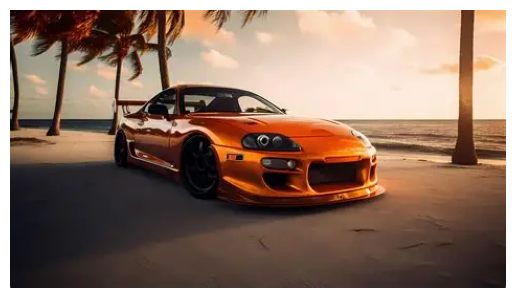

Caption: a photo of a car parked on the beach with palm trees in the background
--------------------------------------------------
Processing: car (1).webp


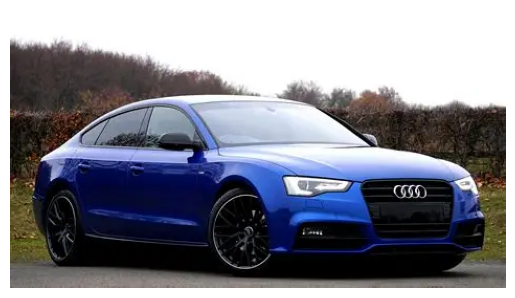

Caption: a photo of a blue audi car parked on the side of a road
--------------------------------------------------


In [13]:
uploaded = files.upload()
for img_name in uploaded.keys():
    print("Processing:", img_name)
    img = Image.open(img_name)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    caption_clean = generate_caption_clean(img_name)
    print("Caption:", caption_clean)
    print("-"*50)

In [14]:
# For normal captions
caption = generate_caption(image_path)
print("Generated Caption:")
print(caption)

# For clean captions (avoid brand names)
caption_clean = generate_caption_clean(image_path)
print("Generated Clean Caption:")
print(caption_clean)

Generated Caption:
a car parked on the beach with palm trees in the background
Generated Clean Caption:
a photo of a car parked on the beach with palm trees in the background
